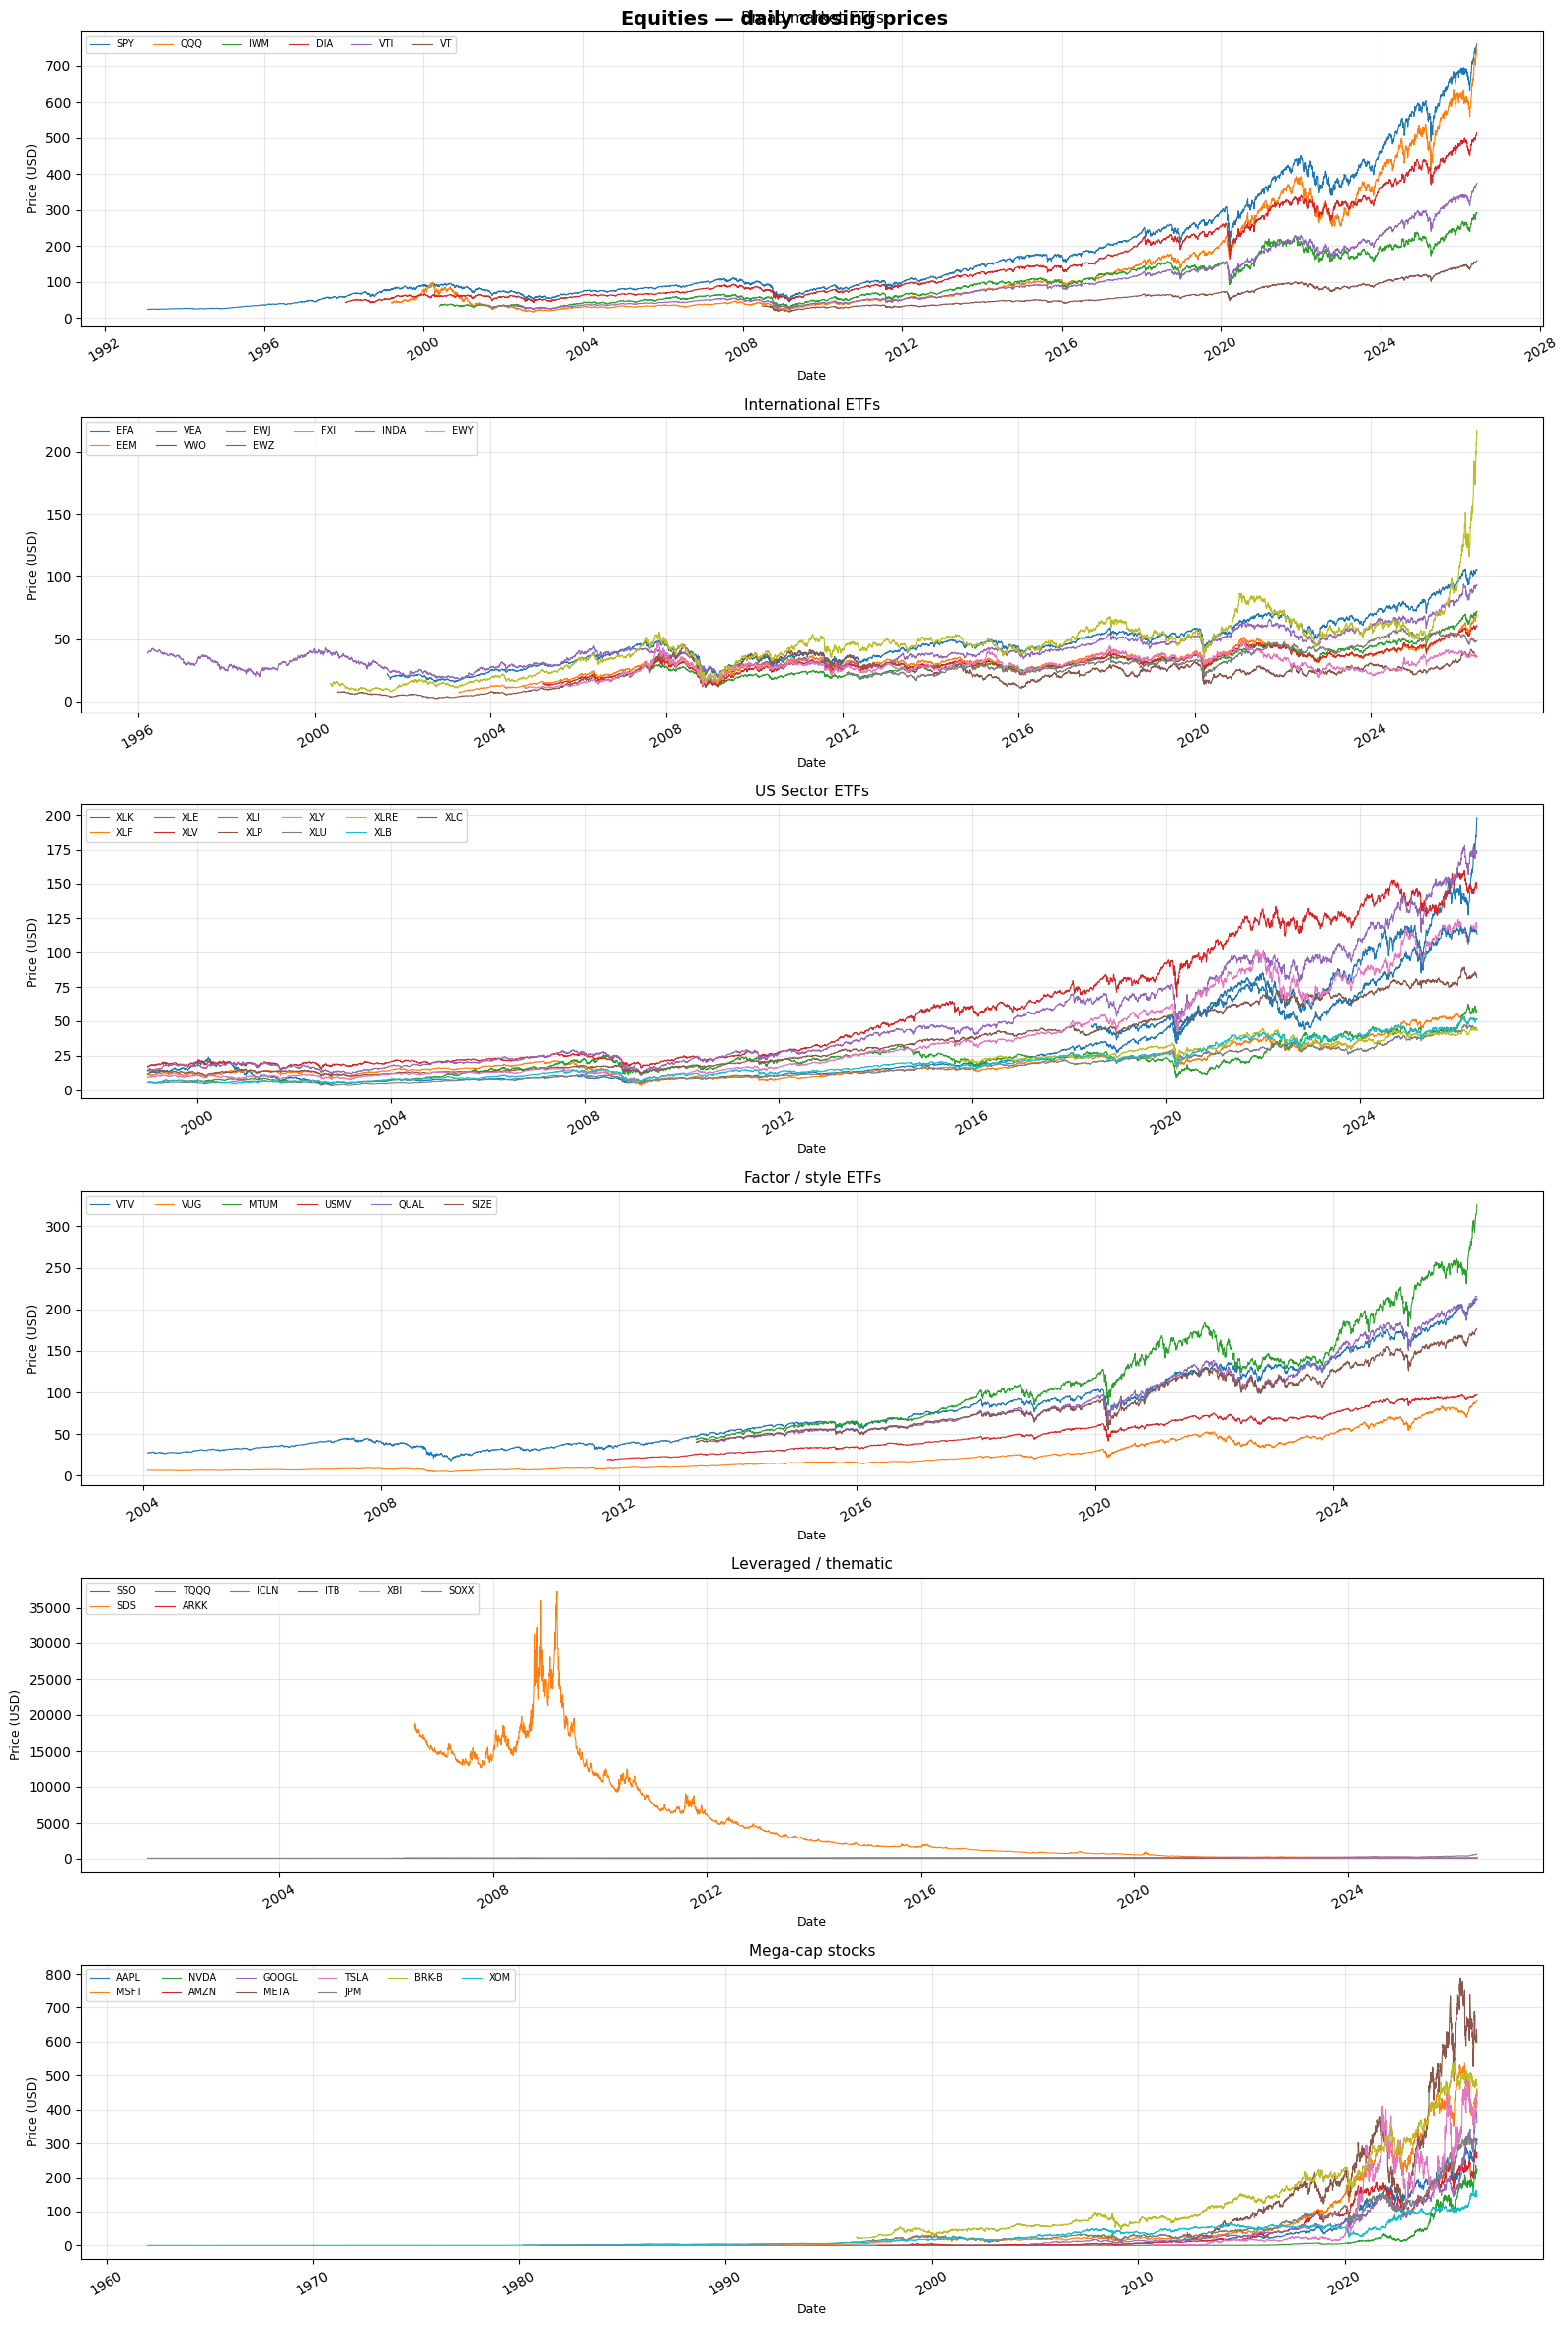

Saved: timeseries_equities.png


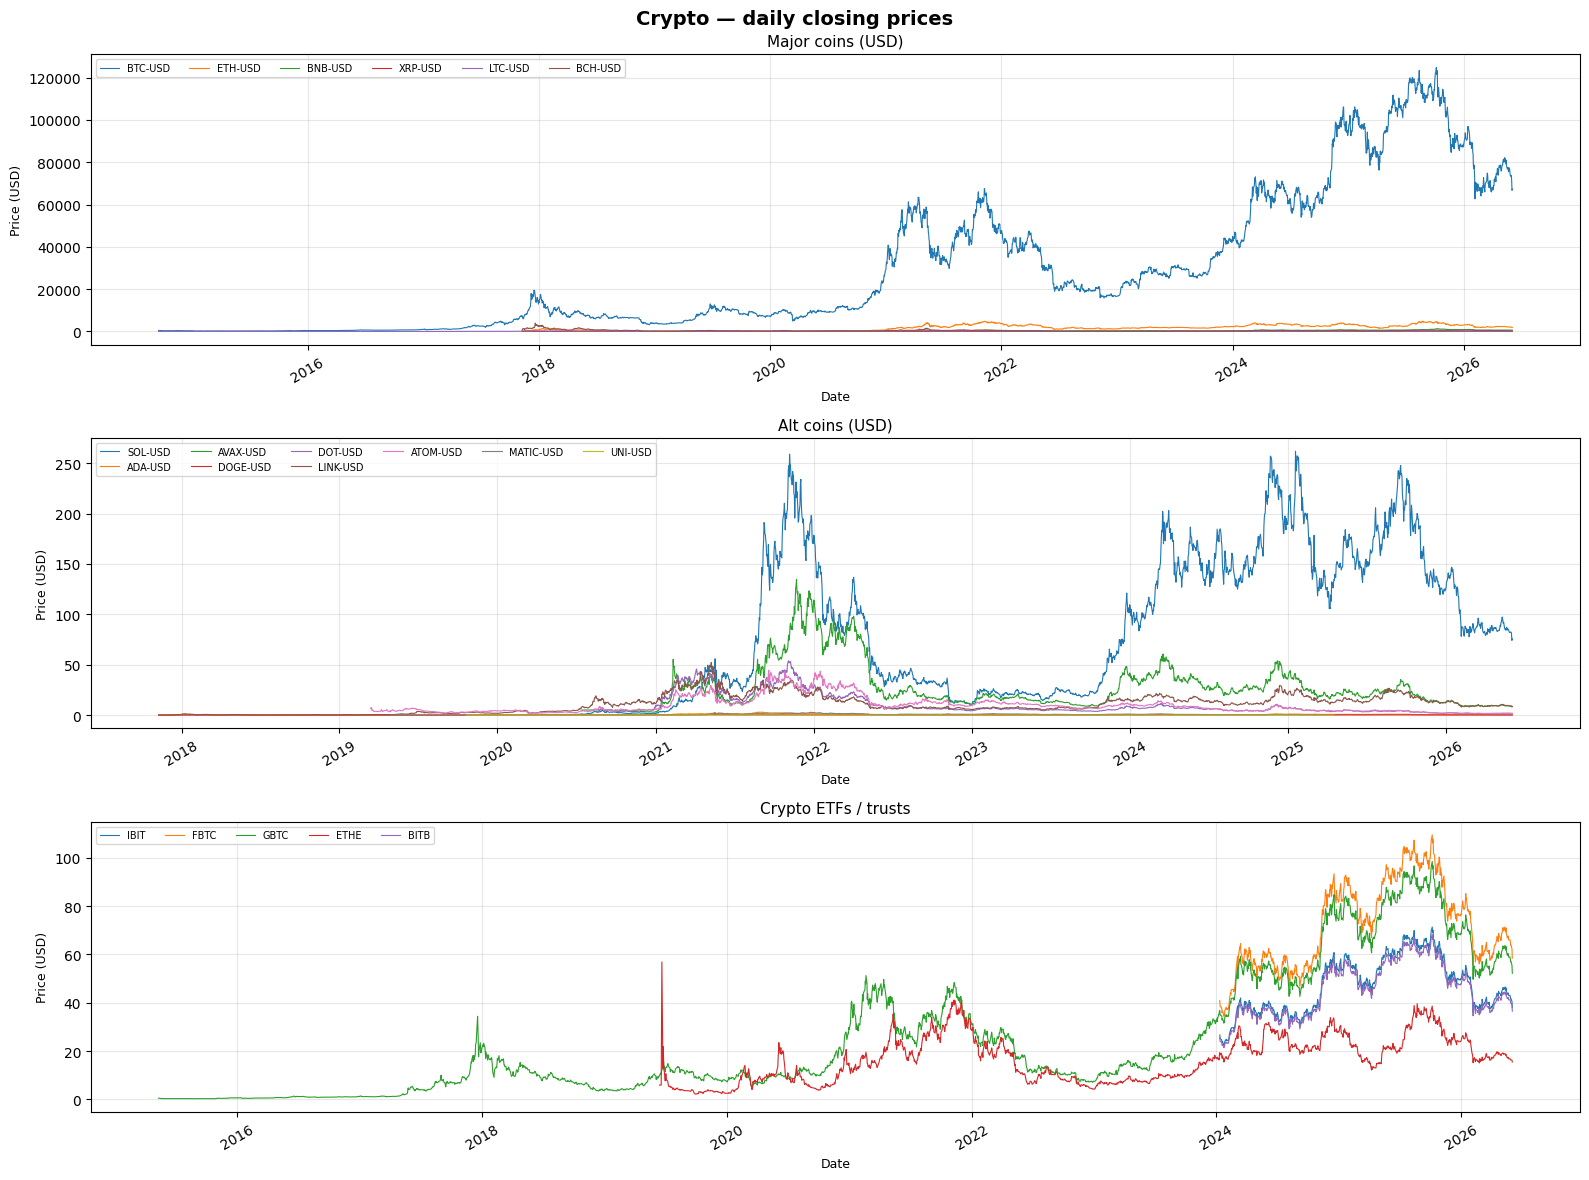

Saved: timeseries_crypto.png


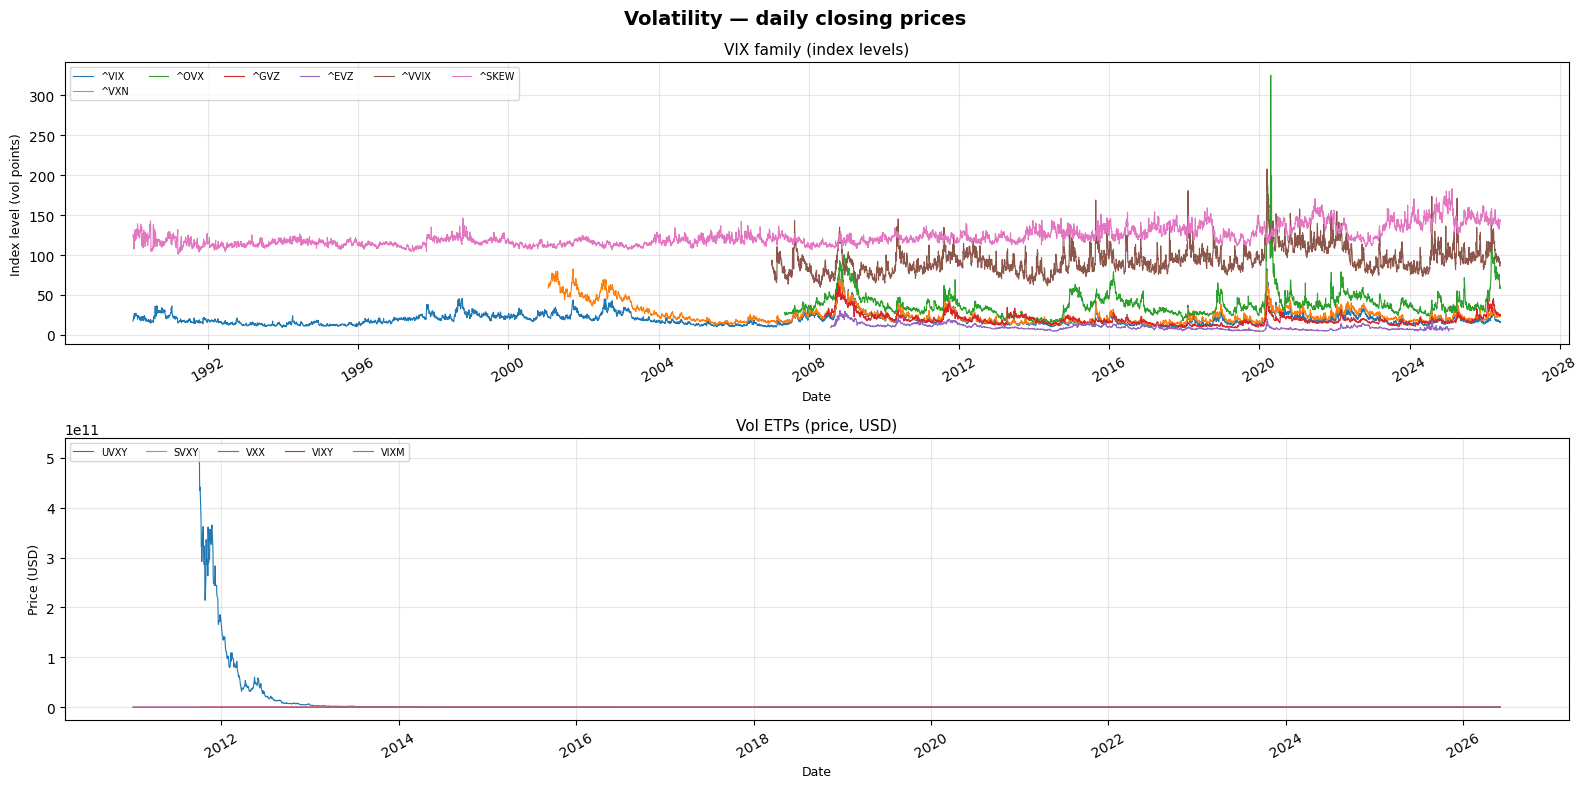

Saved: timeseries_volatility.png


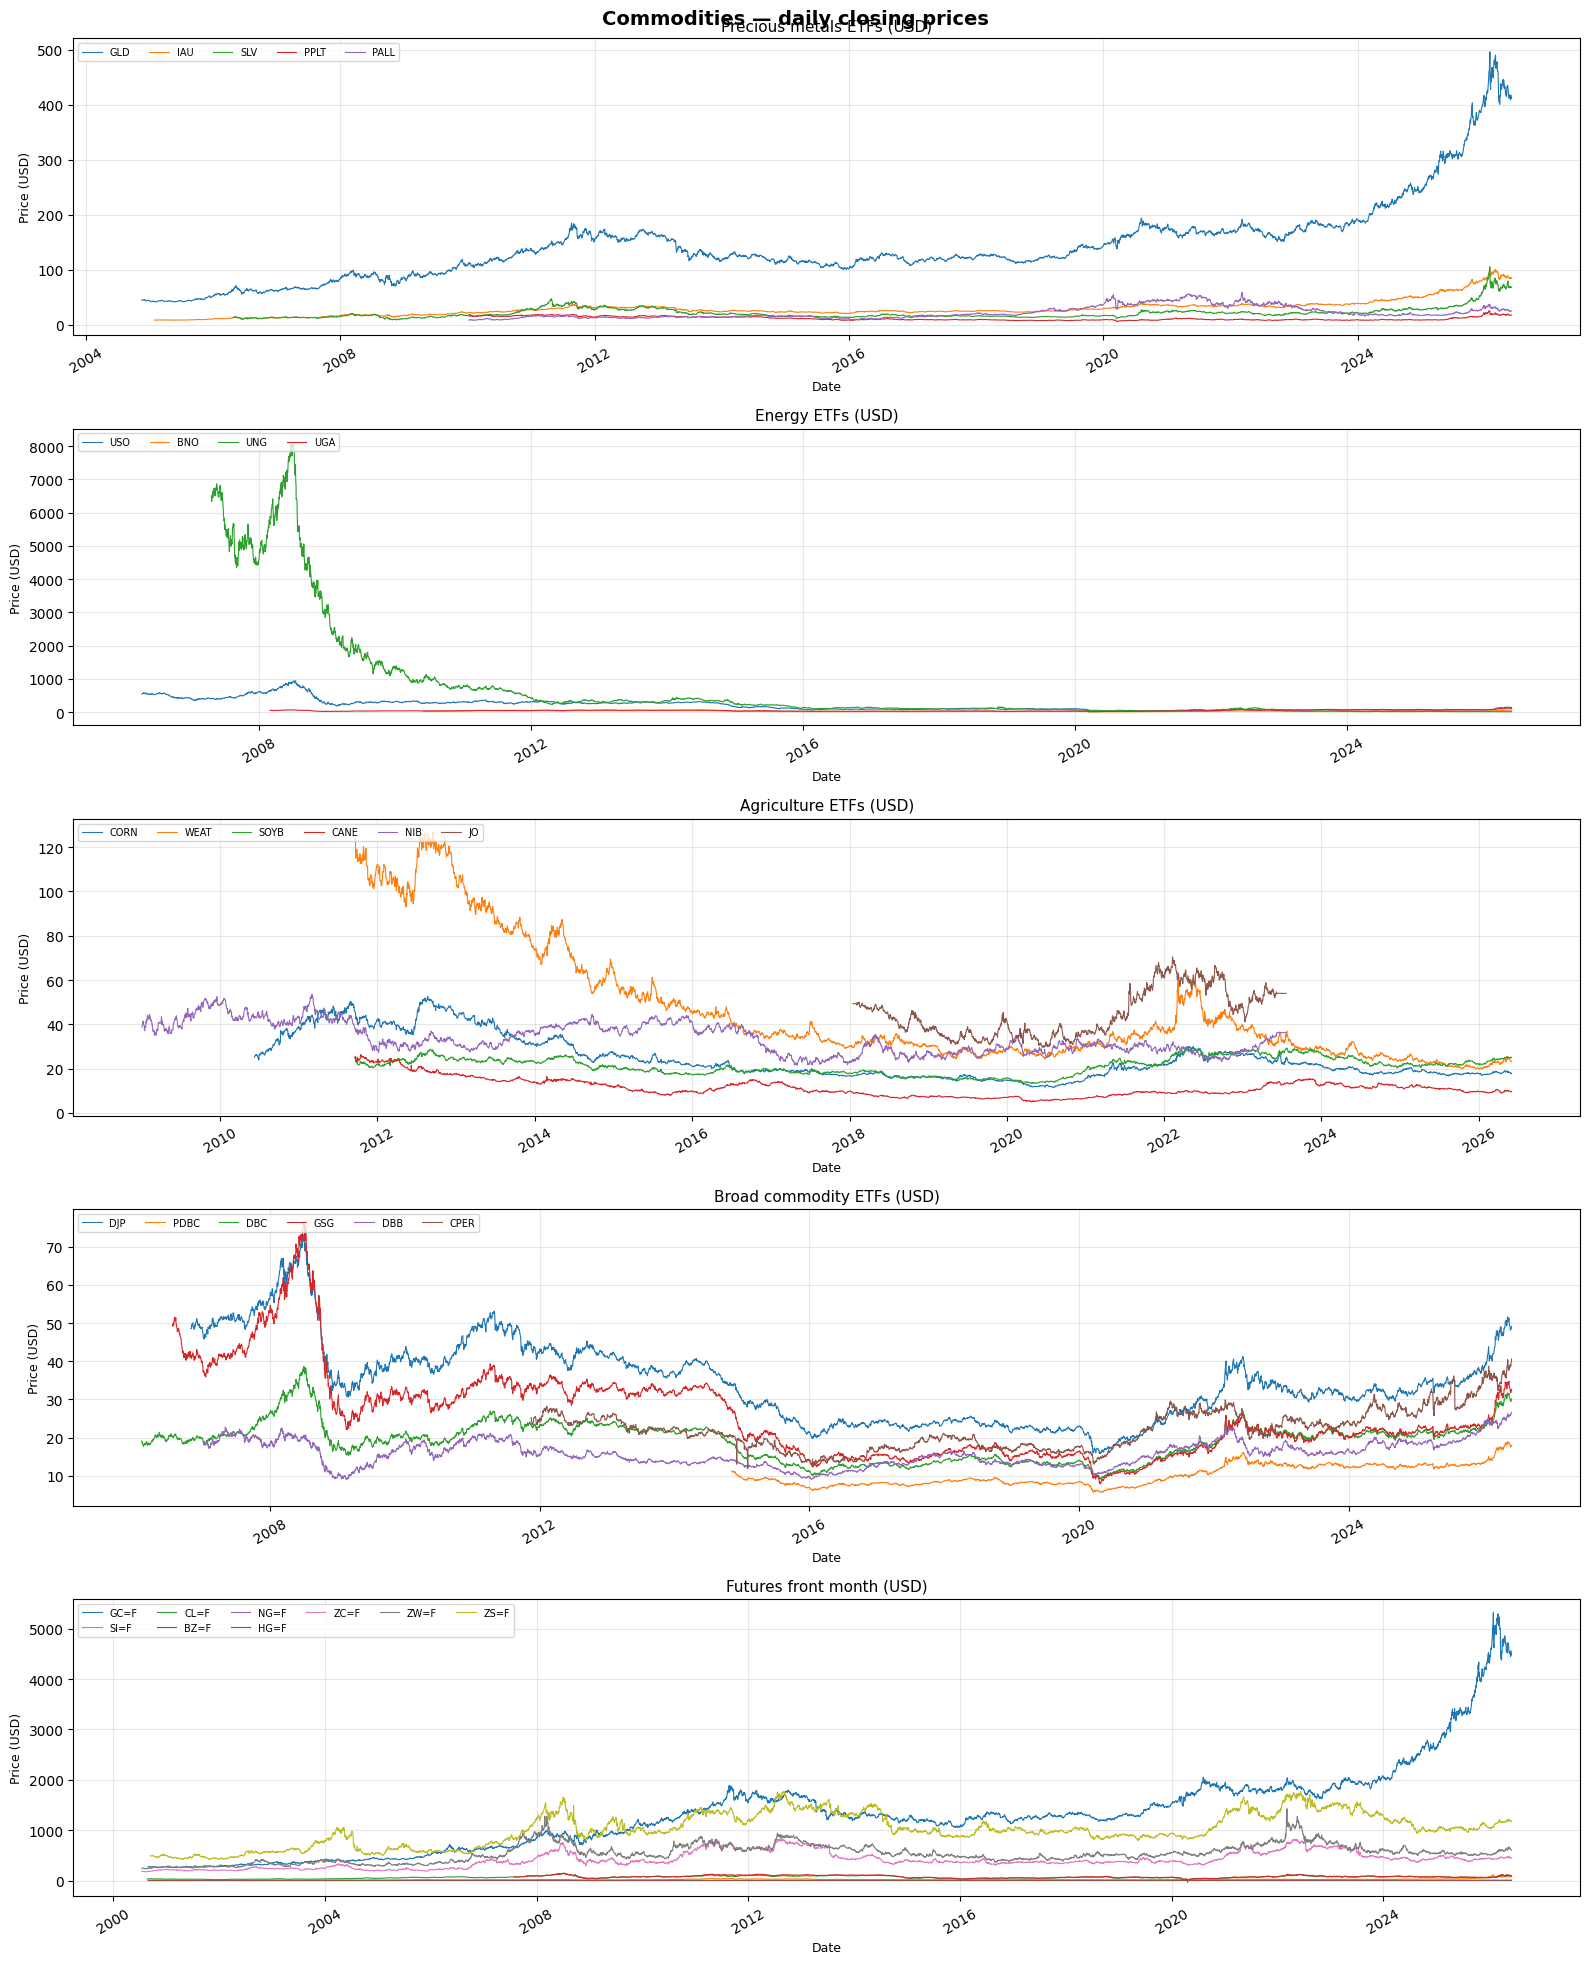

Saved: timeseries_commodities.png


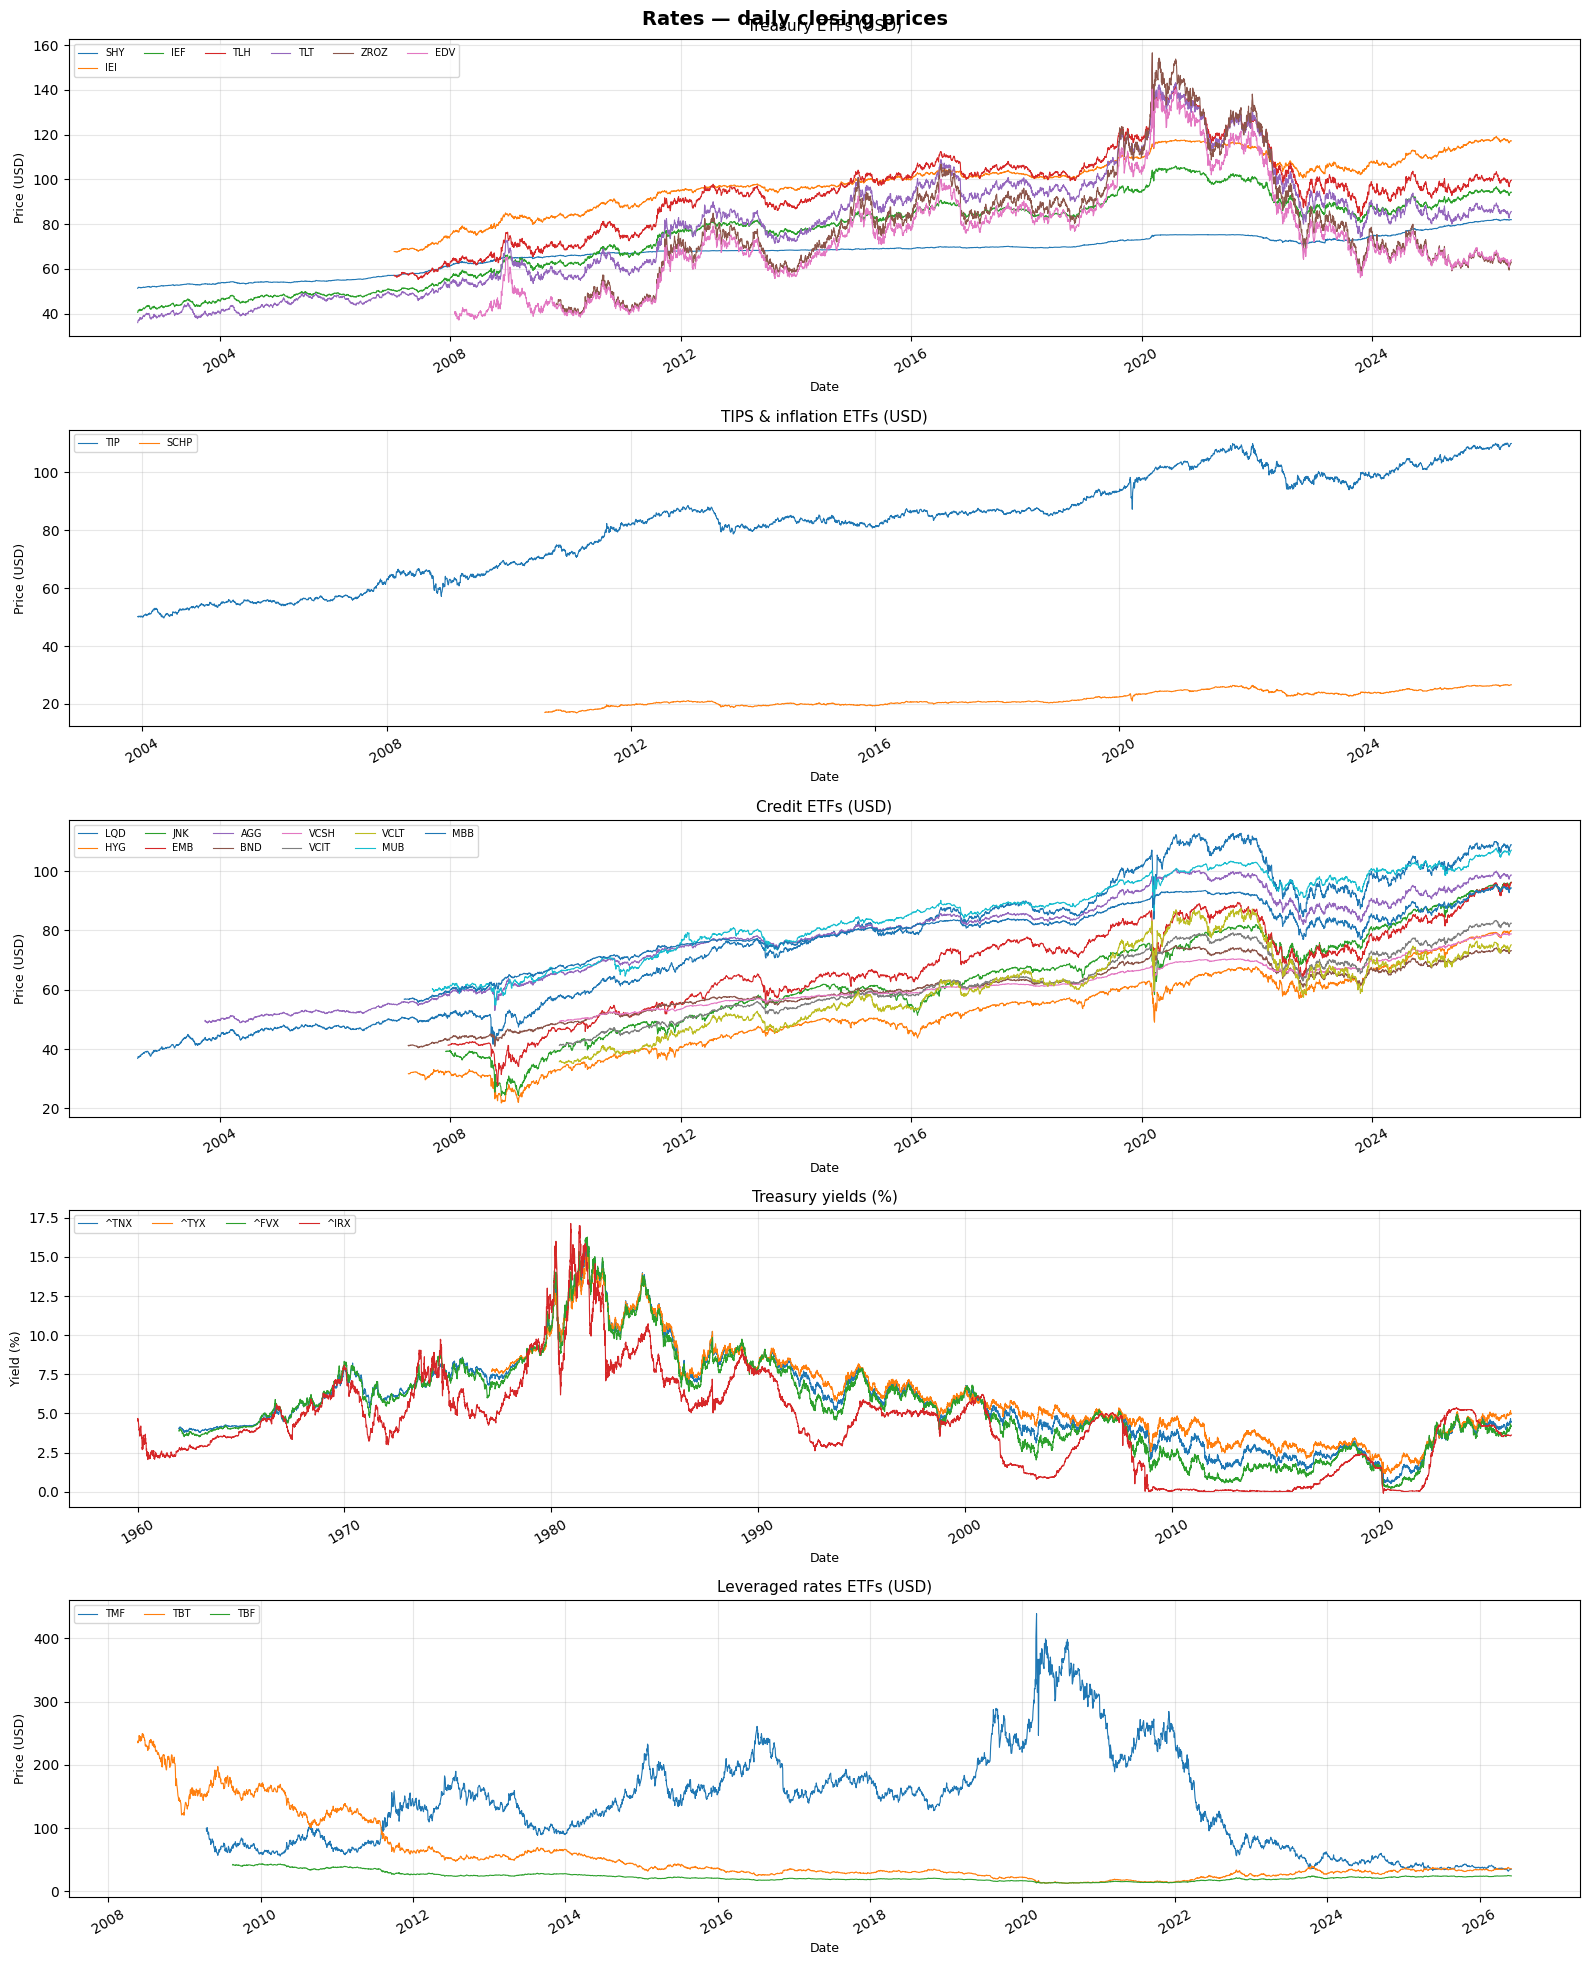

Saved: timeseries_rates.png


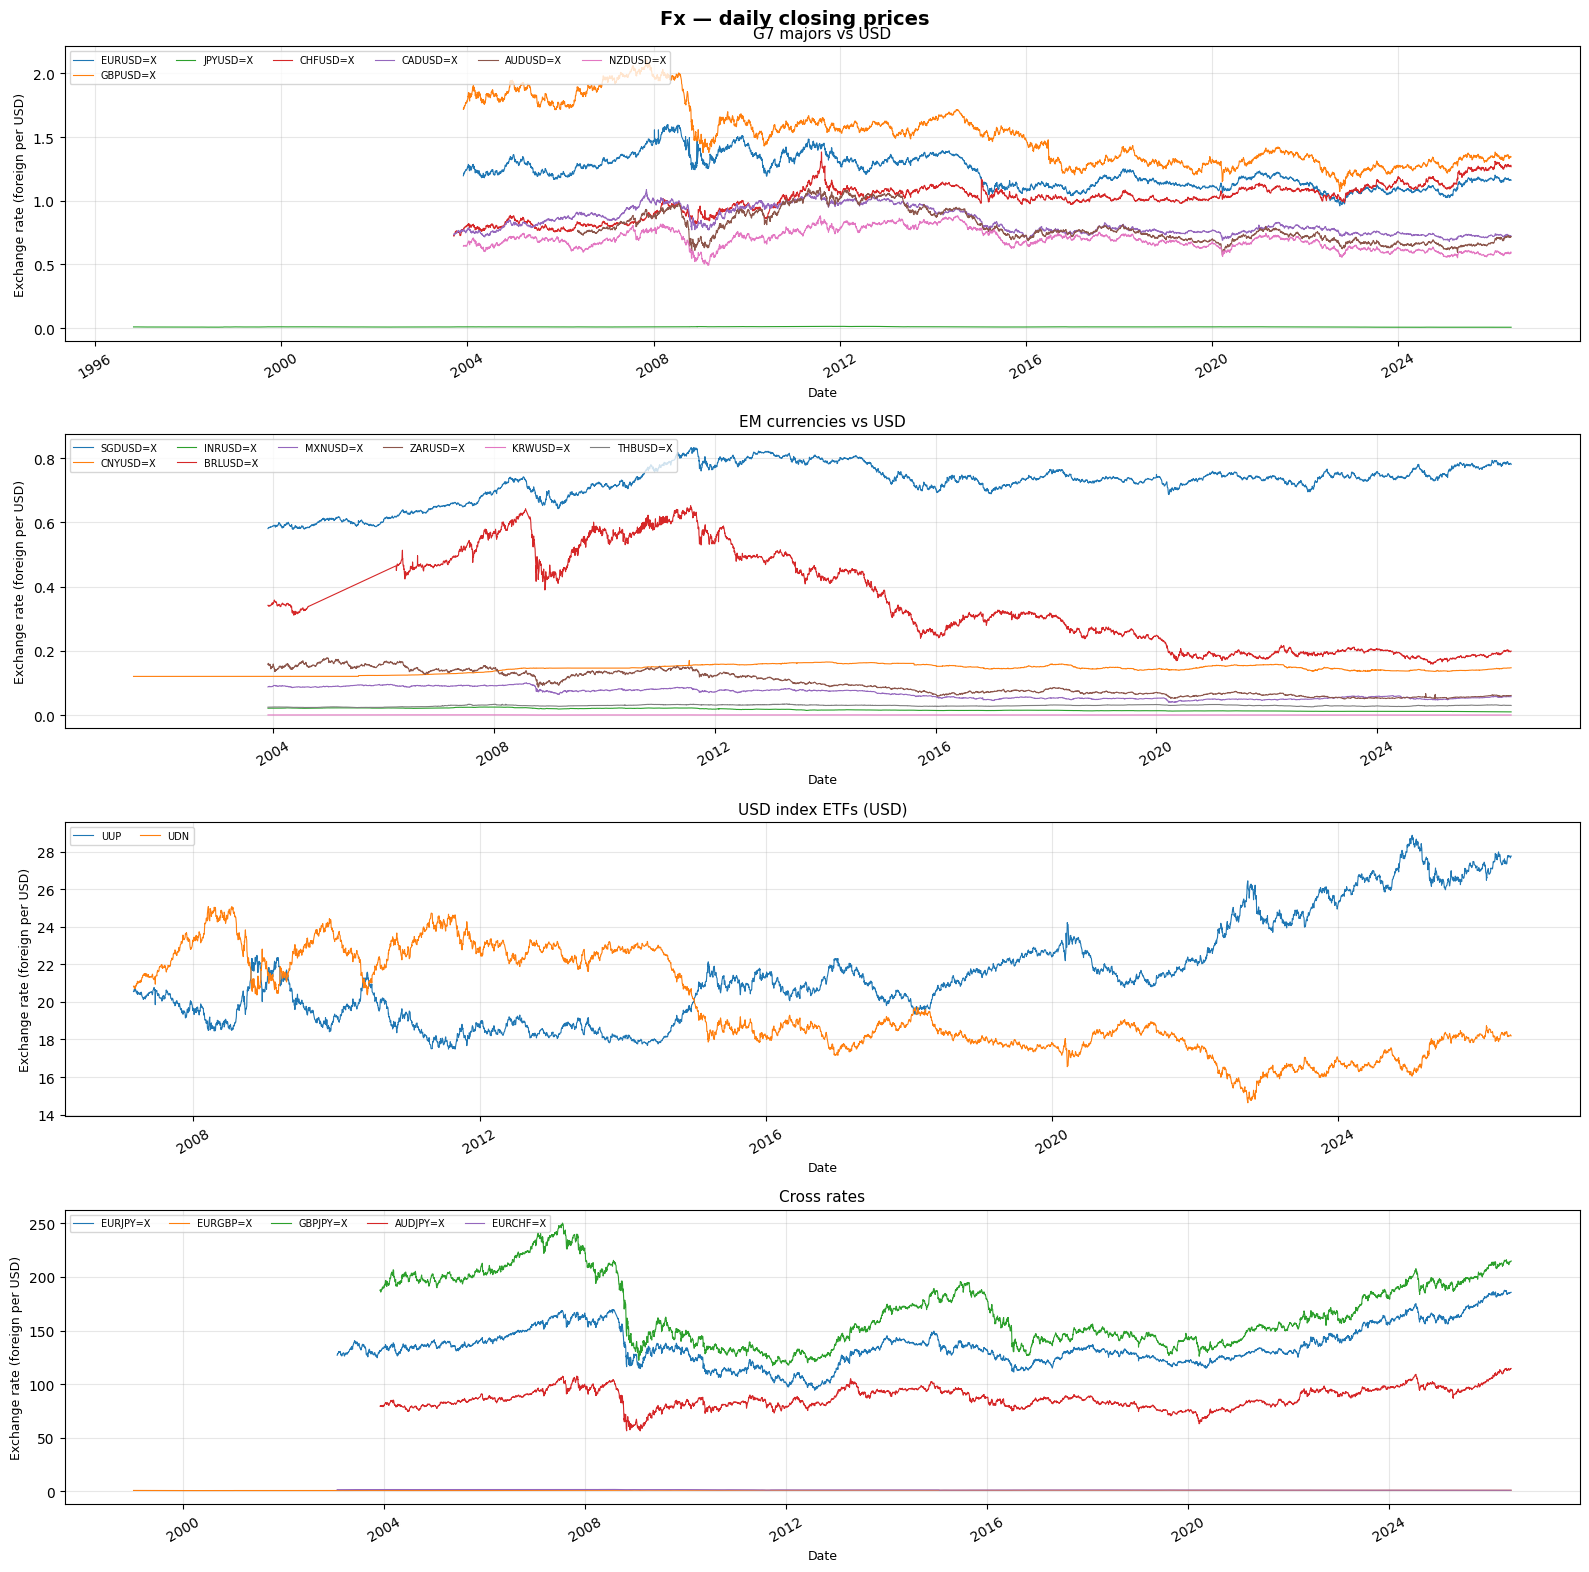

Saved: timeseries_fx.png


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

prices = pd.read_parquet("multiasset_prices.parquet")

subgroups = {
    "equities": {
        "Broad market ETFs":     ["SPY","QQQ","IWM","DIA","VTI","VT"],
        "International ETFs":    ["EFA","EEM","VEA","VWO","EWJ","EWZ","FXI","INDA","EWY"],
        "US Sector ETFs":        ["XLK","XLF","XLE","XLV","XLI","XLP","XLY","XLU","XLRE","XLB","XLC"],
        "Factor / style ETFs":   ["VTV","VUG","MTUM","USMV","QUAL","SIZE"],
        "Leveraged / thematic":  ["SSO","SDS","TQQQ","ARKK","ICLN","ITB","XBI","SOXX"],
        "Mega-cap stocks":       ["AAPL","MSFT","NVDA","AMZN","GOOGL","META","TSLA","JPM","BRK-B","XOM"],
    },
    "crypto": {
        "Major coins (USD)":     ["BTC-USD","ETH-USD","BNB-USD","XRP-USD","LTC-USD","BCH-USD"],
        "Alt coins (USD)":       ["SOL-USD","ADA-USD","AVAX-USD","DOGE-USD","DOT-USD","LINK-USD","ATOM-USD","MATIC-USD","UNI-USD"],
        "Crypto ETFs / trusts":  ["IBIT","FBTC","GBTC","ETHE","BITB"],
    },
    "volatility": {
        "VIX family (index levels)":  ["^VIX","^VXN","^OVX","^GVZ","^EVZ","^VVIX","^SKEW"],
        "Vol ETPs (price, USD)":      ["UVXY","SVXY","VXX","VIXY","VIXM"],
    },
    "commodities": {
        "Precious metals ETFs (USD)": ["GLD","IAU","SLV","PPLT","PALL"],
        "Energy ETFs (USD)":          ["USO","BNO","UNG","UGA"],
        "Agriculture ETFs (USD)":     ["CORN","WEAT","SOYB","CANE","NIB","JO"],
        "Broad commodity ETFs (USD)": ["DJP","PDBC","DBC","GSG","DBB","CPER"],
        "Futures front month (USD)":  ["GC=F","SI=F","CL=F","BZ=F","NG=F","HG=F","ZC=F","ZW=F","ZS=F"],
    },
    "rates": {
        "Treasury ETFs (USD)":        ["SHY","IEI","IEF","TLH","TLT","ZROZ","EDV"],
        "TIPS & inflation ETFs (USD)":["TIP","SCHP"],
        "Credit ETFs (USD)":          ["LQD","HYG","JNK","EMB","AGG","BND","VCSH","VCIT","VCLT","MUB","MBB"],
        "Treasury yields (%)":        ["^TNX","^TYX","^FVX","^IRX"],
        "Leveraged rates ETFs (USD)": ["TMF","TBT","TBF"],
    },
    "fx": {
        "G7 majors vs USD":           ["EURUSD=X","GBPUSD=X","JPYUSD=X","CHFUSD=X","CADUSD=X","AUDUSD=X","NZDUSD=X"],
        "EM currencies vs USD":       ["SGDUSD=X","CNYUSD=X","INRUSD=X","BRLUSD=X","MXNUSD=X","ZARUSD=X","KRWUSD=X","THBUSD=X"],
        "USD index ETFs (USD)":       ["UUP","UDN"],
        "Cross rates":                ["EURJPY=X","EURGBP=X","GBPJPY=X","AUDJPY=X","EURCHF=X"],
    },
}

ylabel_map = {
    "Treasury yields (%)":       "Yield (%)",
    "VIX family (index levels)": "Index level (vol points)",
    "default_price":             "Price (USD)",
    "default_fx":                "Exchange rate (foreign per USD)",
}

for asset_class, groups in subgroups.items():
    n = len(groups)
    fig, axes = plt.subplots(n, 1, figsize=(16, 4 * n), sharex=False)
    if n == 1:
        axes = [axes]
    fig.suptitle(f"{asset_class.capitalize()} — daily closing prices", fontsize=14, fontweight="bold")

    for ax, (group_name, tickers) in zip(axes, groups.items()):
        available = [t for t in tickers if t in prices.columns]
        if not available:
            ax.set_visible(False)
            continue

        for ticker in available:
            s = prices[ticker].dropna()
            ax.plot(s.index, s, linewidth=0.8, label=ticker)

        # y-axis label
        if group_name in ylabel_map:
            ylabel = ylabel_map[group_name]
        elif asset_class == "fx":
            ylabel = ylabel_map["default_fx"]
        else:
            ylabel = ylabel_map["default_price"]

        ax.set_title(group_name, fontsize=11)
        ax.set_xlabel("Date", fontsize=9)
        ax.set_ylabel(ylabel, fontsize=9)
        ax.legend(fontsize=7, ncol=min(len(available), 6), loc="upper left")
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis="x", rotation=30)

    fig.tight_layout()
    plt.savefig(f"timeseries_{asset_class}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: timeseries_{asset_class}.png")